# pyGAlib example: Generation weighted (random) graphs and weighted surrogates
Authors: **Gorka Zamora-López, Ph.D.** and **Matthieu Gilson, Ph.D.**

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<img src="Images/logo_CONECT.png" align="right" width="150" alt="logo CONECT">
<img src="Images/logo_AMU.png" align="right" width="150" alt="logo AMU">


<br>
<br>

---------------------

This notebook illustrate the options in *pyGAlib* to generate weighted graphs and weighted surrogates. In particular we will show how to:

1. add random weights to existing graphs and digraphs,
2. generate (random) weighted (di)graphs, and
3. create surrogate weighted graphs from a given network.

Functions to create both binary and weighted graphs can be found in module *models.py*. As usual, type `help(galib.models)` or `models?` in an interactive Python session to get a list of all network generation functions and, specific instructions for each generating function as `help(galib.FunctionName)` or `galib.FunctionName?`.


## Import dependencies

The Notebook requires a __*Python*__ (>=3.6) installation together with __*NumPy*__ (>1.6) and __*pyGAlib*__ (>=2.1), and __*Matplotlib*__ for the visualizations. Please make sure these packages are installed in the same environment in which this notebook is running.


In [1]:
# 1) Python standard library imports

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local libraries
import galib


## 1. Seeding random weights to existing graphs and digraphs
To begin with, let's generate a small graph (e.g., a star graph) and add random weights to its links, drawn from random number distribution of choice. For that, we will use function `galib.SeedRandomWeights()`. The function accepts: 

1. Two mandatory positional parameters:
    - `adjmatrix` corresponding the (di)graph to which weights will be added, and
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
2. Various optional parameters. We will see them later.
3. Keyword arguments (`**arg_w_distr`) usually related to the random number generator `w_dist`. 

> NOTE: In *pyGAlib* functions to generate binary (di)graphs return 2D *ndarrays* of `np.uint8` dtype. Adding random weights, or generating a new (randomly) weigthed graph returns them in `np.float64` dtype.

### 1.1. – Undirected graphs

Are the networks directed?  net: False  wnet1: False  wnet2: False
Are the weights symmetric?  net: True  wnet1: True  wnet2: True



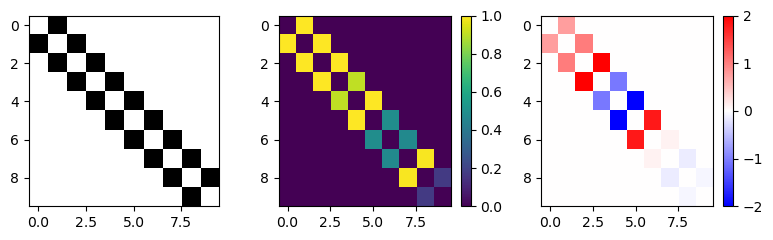

In [2]:
# Create a small graph
N = 10
#net = galib.StarGraph(N)
net = galib.PathGraph(N)

# Create two weigthed versions, seeding weights from a uniform and a normal distributions.
# Parameters of the random number generator are passed as keyword arguments. 
# For the uniform distribution (between 0 and 1) these will be `low = 0` and `high = 1`
wnet1 = galib.SeedRandomWeights(net, np.random.uniform,  low=0, high=2)
# For the normal distribution these will be `loc=0` and `scale=2`.
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  loc=0, scale=2)

# Print some feedback ...
print( f"Are the networks directed?  net: {galib.is_directed(net)}  wnet1: {galib.is_directed(wnet1)}  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are the weights symmetric?  net: {galib.is_symmetric(net)}  wnet1: {galib.is_symmetric(wnet1)}  wnet2: {galib.is_symmetric(wnet2)}" )
print()


# Visualize the generated matrices
plt.figure(figsize=(8,2.5))
plt.subplot(1,3,1)
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wnet1, aspect='auto')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(wnet2, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As seen, symmetric weights were seeded such that $w_{ij} = w_{ji}$. This is because `SeedRandomWeights()` identifies whether the input adjacency matrix represents a directed or and undirected graph and behaves accordingly.

- If the input `adjmatrix` is undirected, then it will seed weights symmetrically.
- Instead, if the input `adjmatrix` is a directed graph, it will seed weigths non-symmetrically.

However, this behaviour can be overwritten using optional parameter `sym_w`. By default `sym_w = None`, which makes the function to first check the directedness of the input matrix `adjmatrix` and behave accordingly. But, setting `sym_w = False` the weights will be randomly assigned ignoring whether the input matrix is an undirected graph or not, and returning an asymmetric connectivity matrix such that $w_{ij} \neq w_{ji}$, in general.

Let's now seed the weights to `net` using `sym_w = False`.

Are the networks directed?  net: False  wnet1: False  wnet2: False
Are the weights symmetric?  net: True  wnet1: False  wnet2: False



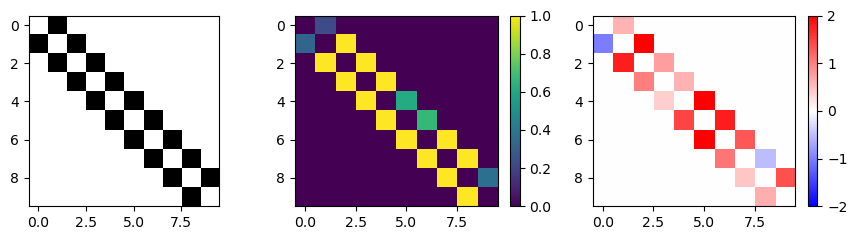

In [3]:
# Set optional parameter sym_w = False
wnet1 = galib.SeedRandomWeights(net, np.random.uniform, sym_w=False,  low=0, high=2)
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  sym_w=False,  loc=0, scale=2)

# Print some feedback ...
print( f"Are the networks directed?  net: {galib.is_directed(net)}  wnet1: {galib.is_directed(wnet1)}  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are the weights symmetric?  net: {galib.is_symmetric(net)}  wnet1: {galib.is_symmetric(wnet1)}  wnet2: {galib.is_symmetric(wnet2)}" )
print()


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wnet1, aspect='auto')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(wnet2, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As expected, the graphs are still undirected but the weights are not symmetric.

On the other hand, we can also overwrite the default option to `sym_w = True`. In this case, 

- if the graph is **undirected** we obtain the default behaviour in which that weights are symmetrically planted. But,
- if the graph is **directed**, then the function distinguishes between reciprocal and non-reciprocal links. It will assign symmetric weights to reciprocal links ($w_{ij} = w_{ji}$ if $A_{ij} = A_{ji} = 1$) while purely directed links receive their own independent weight.


### 1.2. – Directed graphs

By default, if the input `adjmatrix` corresponds to a directed graph, then weights will randomly assigned, without any concerns for symmetry.

Are the networks directed?  dirnet: True   wdirnet: True
Are the weights symmetric?  dirnet: False  wdirnet: False



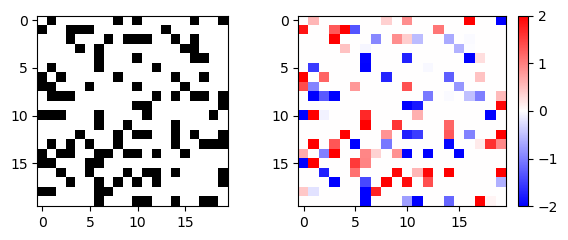

In [4]:
N = 20
linkprob = 0.3

# Create the binary random graph 
dirnet = galib.ErdosRenyiGraph(N,linkprob, directed=True)
# Assign random weights, calling sym_w=True in the directed graph
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal, loc=0,scale=2)

# Print some feedback ...
print( f"Are the networks directed?  dirnet: {galib.is_directed(dirnet)}   \
wdirnet: {galib.is_directed(wdirnet)}" )
print( f"Are the weights symmetric?  dirnet: {galib.is_symmetric(dirnet)}  \
wdirnet: {galib.is_symmetric(wdirnet)}" )
print()


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wdirnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


But, if the `sym_w` parameter is set to `True`, then we will see the following:

Are the networks directed?  dirnet: True   wdirnet: True
Are the weights symmetric?  dirnet: False  wdirnet: False



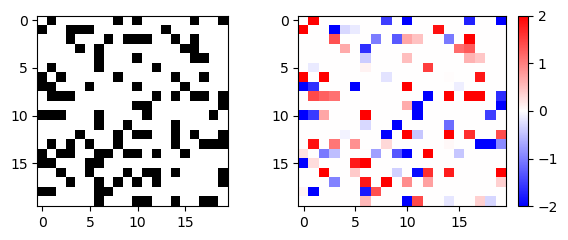

In [5]:
# Assign random weights, calling sym_w=True in the directed graph
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal,  sym_w=True,  loc=0,scale=2)

# Print some feedback ...
print( f"Are the networks directed?  dirnet: {galib.is_directed(dirnet)}   \
wdirnet: {galib.is_directed(wdirnet)}" )
print( f"Are the weights symmetric?  dirnet: {galib.is_symmetric(dirnet)}  \
wdirnet: {galib.is_symmetric(wdirnet)}" )
print()


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wdirnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


It might be difficult to see by looking at the connectivity matrices which links are reciprocal and symmetric, and which are purely directed. To better identify them, we can identify the repriprocal and the directed components, and plot them separately.

Are the networks directed?  wdirnet: True  undirected component: False  directed component: True
Are the weights symmetric?  wdirnet: False  undirected component: True  directed component: False



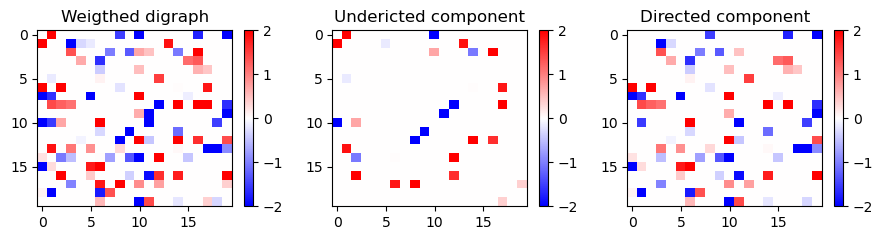

In [6]:
# Define the masks for the reciprocal and the directed components
mask = dirnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wnet_und = wdirnet * mask_und
wnet_dir = wdirnet * mask_dir

# Print some feedback ...
print( f"Are the networks directed?  wdirnet: {galib.is_directed(dirnet)}  \
undirected component: {galib.is_directed(wnet_und)}  directed component: {galib.is_directed(wnet_dir)}" )
print( f"Are the weights symmetric?  wdirnet: {galib.is_symmetric(dirnet)}  \
undirected component: {galib.is_symmetric(wnet_und)}  directed component: {galib.is_symmetric(wnet_dir)}" )
print()


# Visualize the weighted adjacency matrix and the two components separately
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Weigthed digraph' )
plt.imshow(wdirnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Undericted component' )
plt.imshow(wnet_und, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Directed component' )
plt.imshow(wnet_dir, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As we can see clearer now, the reciprocal links received symmetric weights, while directed links are obviously asymmetric.

## 2. Generating weighted random (di)graphs

As shown in the previous section, the function `SeedRandomWeights()` returns a copy of an input `adjmatrix` with random weights added to it. Therefore, weighted random graphs can be generated by creating a binary random graph first, and then adding weights to it. For example:
```python
>>> wrnet = ErdosRenyiGraph(100, 0.05)
>>> wrnet = SeedRandomWeights(wrnet, numpy.random.uniform, low=0, high=1)
```

This procedure will work with any graph we may generate in the first step. Now, given that the two fundamental random graph models $G(N,p)$ and $G(N,L)$ are so commonly used, pyGAlib provides a few shortcuts to generate weighted versions of them. 


### 2.1 - Weighted random (di)graphs from scratch

The following functions are "syntactic sugar" merging the two-call step into into one:

* `galib.models.WeightedERGraph()` 
* `galib.models.WeightedRandomGraph()` 

These generate a random graph of *N* nodes and link probability *p* like in the `ErdosRenyiGraph()` function (*L* links as in the  `RandomGraph()` function), with link weights sampled from a distribution of choice. They inherit the parameters from the previous two functions and from `SeedRandomWeights()`.

* Three mandatory positional parameters:
    - `N`: number of nodes.
    - `p`: link probability (`L`: number of links).
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
* Various optional parameters.
    - `directed`: whether a digraph or a graph is desired.
    - `selfloops`: if generation of self-loops (diagonal entries) is allowed.
    - `sym_w`: whether reciprocal edges will be given the same weight.
* Keyword arguments `**arg_w_distr` usually related to the random number generator `w_dist`. 

As an example, the following cell generates an Erdos-Renyi graph--$G(N,p)$ model--with random weights assigned to the links.

Are the networks directed in ...  wrnet: True  |  undirected component: False  |  directed component: True
Are the weights symmetric in ...  wrnet: False |  undirected component: True  |  directed component: False



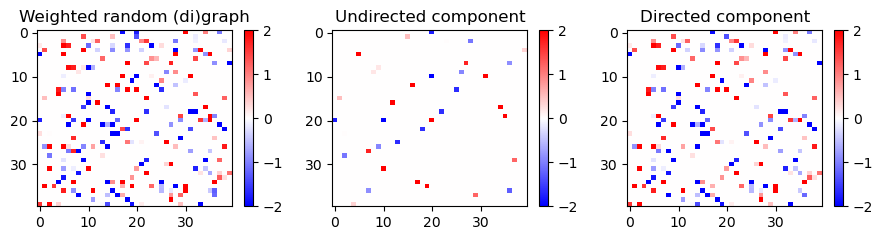

In [7]:
## GENERATE AN ERDOS-RENYI RANDOM (DI)GRAPH WITH RANDOM WEIGHTS
# 1) Define the parameters (EDIT THESE PARAMETERS)
# Positional arguments
N = 40
p = 0.15
w_distr = numpy.random.normal   # e.g., numpy.random.uniform

# Optional arguments
_directed = True   # True, False
_selfloops = True  # True, False
_sym_w = True      # None, True, False

# Keyword arguments of the random distribution. 
# Might need to be changed if other distributions are chosen
_kwargs = {'loc':0, 'scale':2}


# 2) Geneate the random and weighted (di)graph
wrnet = galib.models.WeightedERGraph(N, p, w_distr, 
                                     directed = _directed, 
                                     selfloops = _selfloops, 
                                     sym_w = _sym_w,
                                     **_kwargs)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Visualise the generated (di)graph and check the (un)directed components
# Define the masks for the reciprocal and the directed components
mask = wrnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wrnet_und = wrnet * mask_und
wrnet_dir = wrnet * mask_dir

# Print some feedback ...
print( f"Are the networks directed in ...  wrnet: {galib.is_directed(wrnet)}  |  \
undirected component: {galib.is_directed(wrnet_und)}  |  directed component: {galib.is_directed(wrnet_dir)}" )
print( f"Are the weights symmetric in ...  wrnet: {galib.is_symmetric(wrnet)} |  \
undirected component: {galib.is_symmetric(wrnet_und)}  |  directed component: {galib.is_symmetric(wrnet_dir)}" )
print()


# Visualize the weighted adjacency matrix and the two components separately
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Weighted random (di)graph' )
plt.imshow(wrnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Undirected component' )
plt.imshow(wrnet_und, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Directed component' )
plt.imshow(wrnet_dir, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


### 2.2 - Weighted random (di)graphs from empirical networks

On occasions, random graphs are generated to compare their properties to those of empirical networks. For that, using the previous functions, one needs to first find the main constraints of the empirical network and manually pass them to `WeightedERGraph()` or `WeightedRandomGraph()`. *pyGAlib* offers two options to facilitate this. Functions

* `galib.models.ErdosRenyiGraph_Like(adjmatrix, ...)` and
* `galib.models.RandomGraph_Like(adjamatrix, ...)` 

will first automatically identify the core (binary) constraints of an input matrix (i.e., its size, density, number of links, directedness, symmetry, etc.) and will then generate an equivalent random graph. By default, the functions return a binary random graph but a random weight distribution can also be optionally given, as in the examples above.

The following example does the following:

1. Loads an empirical network (*realnet*)
2. Generates an equivalent random (di)graph of same size, directedness and number of links.
3. Generates an equivalent random (di)graph with random link weights.

The given *realnet* can be either directed or undirected, binary or weighted. Although if it is weighted, the functions will ignore those weigths and seed them from the chosen distribution. In the next section we will show how to generate surrogates employing the original weights from the input matrix.

##### Generate a binary random graph

Is the network directed?  Empirical: False  |  random: False 
Number of nodes N ...	Empirical: 77  |  random: 77 
Density of the net ...	Empirical: 0.0868  |  random: 0.0868 
Number of links L ...	Empirical: 508  |  random: 508 
Number self-loops ...	Empirical: 0  |  random: 0 



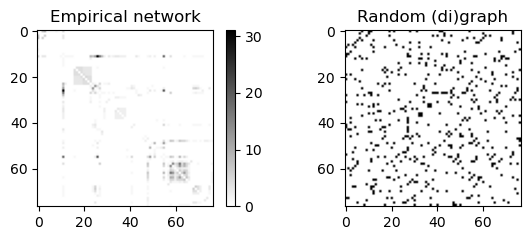

In [8]:
## GENERATING A RANDOM BINARY GRAPH, FROM AN EMPIRICAL NETWORK
# 1) Load an empirical network (CHOOSE ONE)
dataroot = "./Data/"
# realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
# realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)

# 2) Generate an equivalent binary random graph (CHOOSE ONE)
# rnet = galib.models.ErdosRenyiGraph_Like(realnet)
rnet = galib.models.RandomGraph_Like(realnet)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Compare their main characteristics
dir_real = galib.is_directed(realnet)
dir_rand = galib.is_directed(rnet)
print( f'Is the network directed?  Empirical: {dir_real}  |  random: {dir_rand} ' )

Nreal = len(realnet); Nrand = len(rnet)
print( f'Number of nodes N ...\tEmpirical: {Nreal:d}  |  random: {Nrand:d} ' )

dens_real = galib.Density(realnet)
dens_rand = galib.Density(rnet)
print( f'Density of the net ...\tEmpirical: {dens_real:1.4f}  |  random: {dens_rand:1.4f} ' )

Lreal = realnet.astype(bool).sum()
Lrand = rnet.sum()
print( f'Number of links L ...\tEmpirical: {Lreal:d}  |  random: {Lrand:d} ' )

Lreal_diag = realnet.astype(bool).trace()
Lrand_diag = rnet.trace()
print( f'Number self-loops ...\tEmpirical: {Lreal_diag:d}  |  random: {Lrand_diag:d} ' )
print()


# 3) Plot the two adjacency matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Random (di)graph' )
plt.imshow(rnet, cmap='gray_r')

plt.tight_layout()

#

##### Generate a weighted random graph

Is the network directed?  Empirical: False  |  random: False 
Number of nodes N ...	Empirical: 34  |  random: 34 
Density of the net ...	Empirical: 0.1390  |  random: 0.1390 
Number of links L ...	Empirical: 156  |  random: 156 
Number self-loops ...	Empirical: 0  |  random: 0 



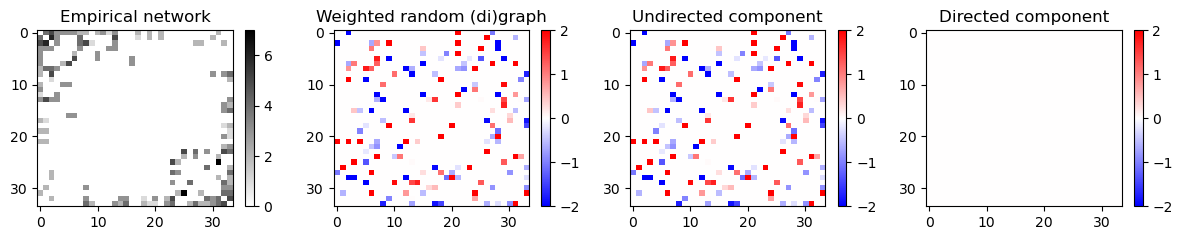

In [10]:
## GENERATING A RANDOM GRAPH OF G(N,L) TYPE WITH RANDOM WEIGHTS, FROM AN EMPIRICAL NETWORK

# 1) Load an empirical network (CHOOSE ONE)
dataroot = "./Data/"
# realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
# realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)


# 2) Generate an equivalent random graph with random weights
# Edit the parameters regarding the weight distribution
_sym_w = None      # None, True, False

_w_distr = numpy.random.normal   # e.g., numpy.random.uniform
_kwargs = {'loc':0, 'scale':2}

# Generate the matrix
wrnet = galib.models.RandomGraph_Like(realnet, sym_w=_sym_w, w_distr=_w_distr, **_kwargs)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Compare their main characteristics
dir_real = galib.is_directed(realnet)
dir_rand = galib.is_directed(wrnet)
print( f'Is the network directed?  Empirical: {dir_real}  |  random: {dir_rand} ' )

Nreal = len(realnet); Nrand = len(wrnet)
print( f'Number of nodes N ...\tEmpirical: {Nreal:d}  |  random: {Nrand:d} ' )

dens_real = galib.Density(realnet)
dens_rand = galib.Density(wrnet)
print( f'Density of the net ...\tEmpirical: {dens_real:1.4f}  |  random: {dens_rand:1.4f} ' )

Lreal = realnet.astype(bool).sum()
Lrand = wrnet.astype(bool).sum()
print( f'Number of links L ...\tEmpirical: {Lreal:d}  |  random: {Lrand:d} ' )

Lreal_diag = realnet.astype(bool).trace()
Lrand_diag = rnet.astype(bool).trace()
print( f'Number self-loops ...\tEmpirical: {Lreal_diag:d}  |  random: {Lrand_diag:d} ' )
print()


# 4) Plot the adjacency matrices
# Define the masks for the reciprocal and the directed components
mask = wrnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wrnet_und = wrnet * mask_und
wrnet_dir = wrnet * mask_dir

# Plot the figure
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r', aspect='auto')
plt.colorbar()

plt.subplot(1,4,2)
plt.title( 'Weighted random (di)graph' )
plt.imshow(wrnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wrnet_und, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wrnet_dir, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


> **Note that**, if `ErdosRenyi_Like()` and `RandomGraph_Like()` are called to return a binary (digraph), they return a matrix of `np.uint8` ndtype. If weights are seeded, then a matrix of `np.float64` ndtype is returned.

## 3. Generation of weighted surrogate networks

write me here … Surrogate generation always depends on the question we want to answer, which defines what we want to compare with.

* Generate or load one graph, use `SeedRandomWeights()` to generate many realizations, from one graph.
* Using `WeightedERGraph()` and `WeightedRandomGraph()` to generate. 
* Using `ErdosRenyiGraph_Like()` and `RandomGraph_Like()` (the most classical case, in guess).
* Using `ShuffleWeights()` to randomise only the weights.

FINISH THIS SECTION !!